# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [44]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [45]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [46]:
# muestra las primeras 5 filas
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [47]:
# muestra las primeras 5 filas
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [48]:
# muestra las primeras 5 filas
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [49]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [50]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [51]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [52]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [53]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

# proporción de nulos para users
print("\nProporción de valores nulos:")
print(users.isna().mean())

# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

# proporción de nulos para usage
print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64
Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  

**Dataset users**
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- **City con 11.72%**  y  **churn_date con 88.35%**
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En city: investigar y probablemente imputar y churn_date: probablemente ignorar

**Dataset usage**
- Qué columnas tienen valores faltantes y en qué proporción?
- **Date con .001%**,  **duration con 55.19%** y **length con 44.74%**
- Indica qué harías: imputar, eliminar, ignorar?
- En date: probablemente dejar como nulos, duration: probablemente ignorar y length: probablemente ignorar


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [54]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [55]:
(users['age'] == -999).sum()

55

- La columna `user_id` **muestra un resumen estadístico dentro de un rango coherente, no presenta ningún sentinel.**
- La columna `age` **presenta un valor sospechoso, un sentinel en min de: -999 (equivalente a 55 datos).**

In [56]:
# explorar columnas numéricas de usage
usage[['id', 'user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id` **presentan rangos coherentes y no se observan valores numéricos evidentemente inválidos**
- Las columnas **muestra consistencia en el rango observado en el dataset usage.**

In [57]:
# explorar columnas categóricas de users
columns_user = ['city', 'plan']

for columna in columns_user:
    print(columna)
    print(users[columna].unique())
    print()

(users['city'] == '?').sum()

city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

plan
['Basico' 'Premium']



96

- La columna `city` **nos indica que tenemos valores categóricos desconocidos: 469 datos de 4000 (96 ciudades desconocidas (?) y 373 valores ausentes(nan))** 
- La columna `plan` **no presenta ningún valor que requiera atención**

In [58]:
# explorar columna categórica de usage
usage['type'].unique()
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` **nos indica que tenemos los 40,000 datos clasificados en alguna de las 2 categórias posibles: text o call**


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- **En el dataset Users las columnas: age (sentinel: -999) y en city (valores aucentes: nan y sentinels: ?)**
- ¿Qué acción tomarías? 
- **En la columna age covertiría a (nan) y luego imputaria con la mediana (tomando en cuenta que son 55 datos) y para city imputaria con la categoria ("Unknown").**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [59]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [60]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [61]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, **tenemos 40 datos con fecha de 2026 al paracer fuera del rango de análisis**

In [62]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, **tenemos 50 posibles valores ausentes, diferentes a 2024.** 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- **Aparecen distintos años, sin embargo el año 2026 que aún no transcurre, para ser un año no posible, se propone inicialmente mantener los valores como invalidos (Na), pero excluirlos para análisis futuros, que dependan del tiempo**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En`city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [67]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [69]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 

**Los valores nulos en duration y length, dependen del tipo de uso (type), ya que cada variable aplica únicamente a una categoría: duration para call y length para text. Por lo tanto, los nulos son estructurales/MAR y no representan datos faltantes que deban imputarse.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [70]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_text=('is_text', 'sum'),
    total_call=('is_call', 'sum'),
    total_min_call=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_text,total_call,total_min_call
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'total_text': 'cant_mensajes',
    'total_call': 'cant_llamadas',
    'total_min_call': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [72]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [73]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [74]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

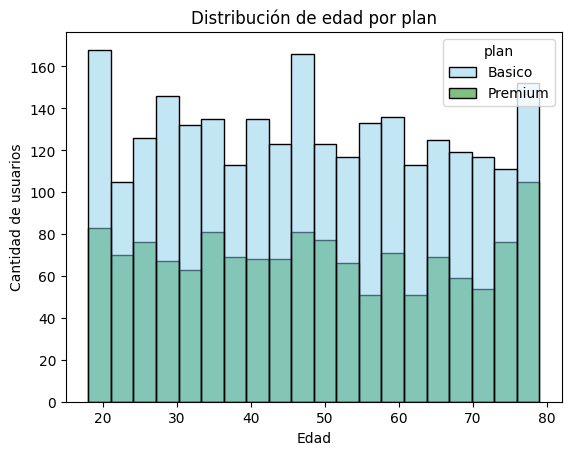

In [75]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, x='age', hue='plan', bins=20, palette=['skyblue', 'green'])

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución: **La distribución de edad es relativamente uniforme, sin un sesgo evidente hacia la izquierda o derecha. Los usuarios de ambos planes están distribuidos a lo largo de un rango amplio de edades.**

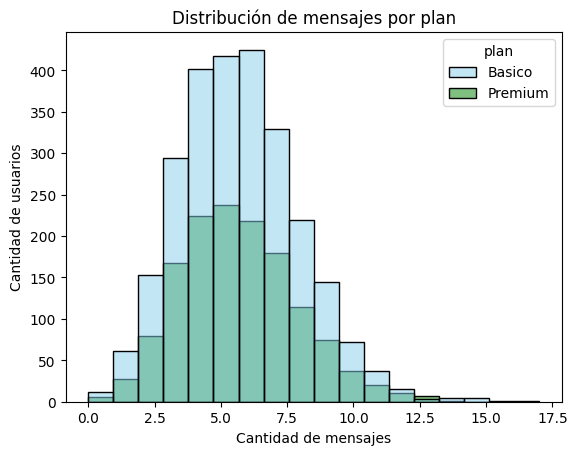

In [76]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile, x='cant_mensajes', hue='plan', bins=18, palette=['skyblue', 'green']
)

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **La distribución de mensajes presenta un sesgo moderado hacia la derecha. La mayor concentración de usuarios se encuentra aproximadamente entre 4 y 7 mensajes, con un máximo alrededor de 5-6 mensajes. Existen pocos usuarios con un número considerablemente mayor de mensajes, formando una cola hacia valores altos. Ambos planes presentan una distribución similar.**

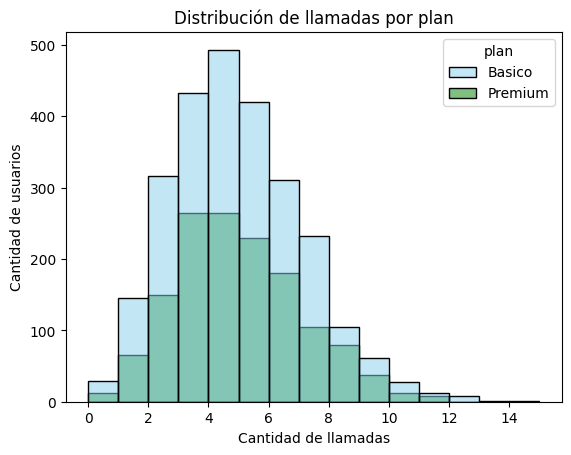

In [77]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile, x='cant_llamadas', hue='plan',bins=15, palette=['skyblue', 'green']
)

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución: **La distribución de llamadas presenta una concentración principalmente entre 4 y 5 llamadas por usuario. Se observa un sesgo leve hacia la derecha, aunque la distribución es relativamente equilibrada. Los usuarios de los planes Básico y Premium muestran una forma de distribución similar.**

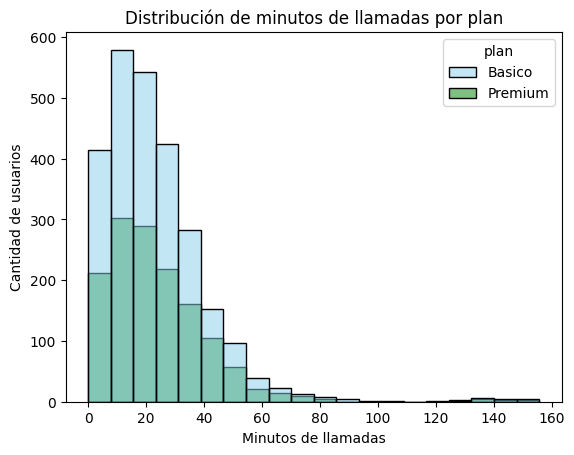

In [78]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue', 'green']
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- **La distribución de los minutos de llamadas presenta un sesgo hacia la derecha. La mayoría de los usuarios concentra su consumo en niveles relativamente bajos o moderados, mientras que un grupo reducido presenta consumos mucho mayores, generando una cola hacia valores altos. El comportamiento visual es similar entre los planes Básico y Premium.**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

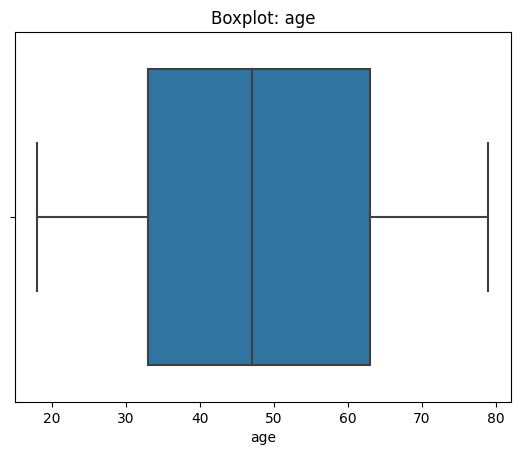

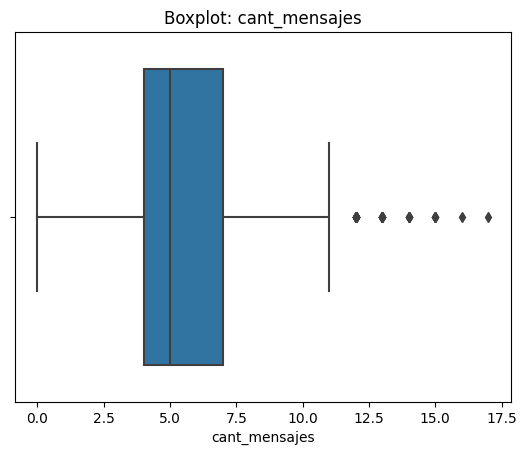

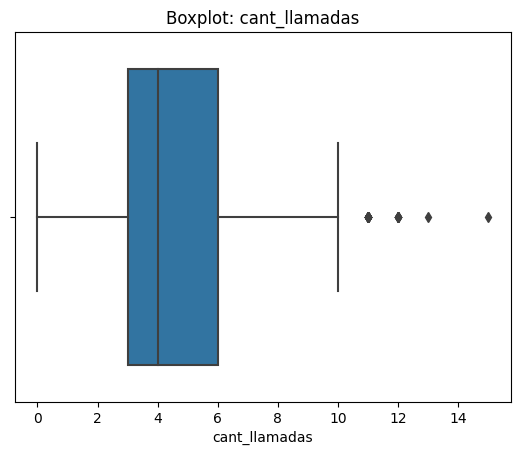

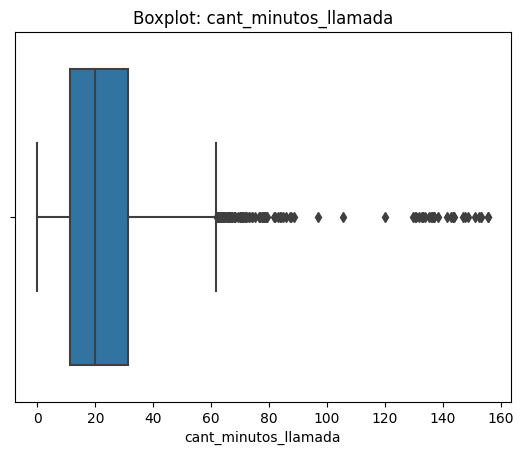

In [79]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: **No presenta outlies.**
- cant_mensajes: **Presenta outliers.**
- cant_llamadas: **Presenta outliers.**
- cant_minutos_llamada: **Presenta outliers.**

In [80]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(col, '→ límite superior:', limite_superior)


cant_mensajes → límite superior: 11.5
cant_llamadas → límite superior: 10.5
cant_minutos_llamada → límite superior: 61.8575


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: **Se propone mantener los outliers, debido a que no se observa que dichos valores sean errores de registro, pero deberán considerarse al realizar análisis posteriores**

- cant_llamadas: **Los outliers se mantendrán como propuesta inicial, puesto que no se observa que dichos valores sean errores de registro, pero deberán considerarse al realizar análisis posteriores.**

- cant_minutos_llamada: **Los outliers se mantendrán para no perder información potencialmente relevante, debido a que no se observa que dichos valores sean errores de registro, ya que pueden representar usuarios con un nivel de uso elevado y podrían ser relevantes para análisis posteriores.**

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
# Crear columna grupo_uso
import numpy as np

user_profile['grupo_uso'] = np.select(
    [(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
     (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)],
    
    ['Bajo uso','Uso medio'],
    default='Alto uso'
)

In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:
# Crear columna grupo_edad
grupo_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(grupo_edad, valores_edad,
    default='Adulto Mayor'
)

In [85]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

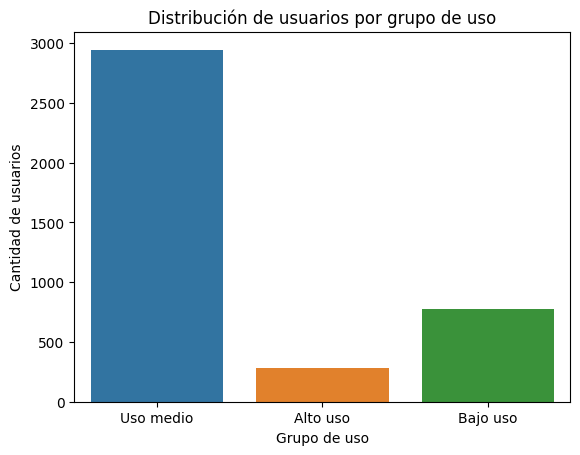

In [86]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

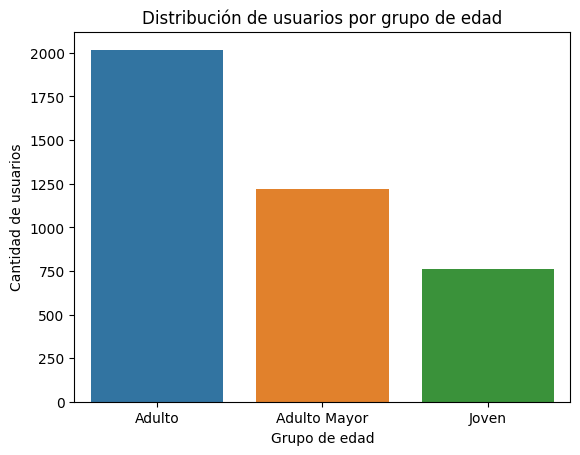

In [87]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()

### 7.4. 6.4  Consultas de Apoyo para Análisis e Insight Ejecutivo

In [88]:
# Conteo por grupo de uso
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [89]:
# Conteo por grupo de edad
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [90]:
# Tabla de grupo de uso vs tipo de plan
pd.crosstab(
    user_profile['grupo_uso'],
    user_profile['plan'],
    normalize='columns'
) * 100

plan,Basico,Premium
grupo_uso,,
Alto uso,7.167630,6.619217
Bajo uso,19.730250,18.932384
Uso medio,73.102119,74.448399


In [91]:
# Porcentaje de abandono por grupo de uso
user_profile['churn'] = user_profile['churn_date'].notna()
user_profile.groupby('grupo_uso')['churn'].mean() * 100

grupo_uso
Alto uso     13.978495
Bajo uso     11.439589
Uso medio    11.484879
Name: churn, dtype: float64

In [92]:
# Total de usuarios que abandonaron
user_profile['churn_date'].notna().sum()

466


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Los principales problemas de calidad no implicaron necesariamente eliminar registros. La estrategia aplicada fue conservar la mayor cantidad posible de información, corrigiendo valores inválidos y diferenciando los valores realmente faltantes de aquellos que representan información no aplicable.

- **"city"**: se identificaron 469 registros sin ciudad válida (11.73%), de los cuales 373 eran NaN y 96 utilizaban '?' como valor desconocido. Se decidió conservar los usuarios y tratar estos valores como información faltante.

- **"churn_date"**: existen 3,534 valores nulos (88.35%). Estos valores no se eliminaron porque representan usuarios que probablemente no han abandonado el servicio, y no representan una afectación para el presente análisis.

- **"age"**: se detectó el valor -999, utilizado como valor atípico/sentinel de dato desconocido. Se trató como valor inválido y se realizó la imputación correspondiente con la mediana.

- **"reg_date"**: se encontraron 40 registros con año 2026, fuera del periodo esperado del análisis. Se conservaron los usuarios, pero se marcaron esas fechas como faltantes (NaT) para evitar distorsionar el análisis temporal.

- **"date"**: se identificaron 50 registros con fechas inválidas o faltantes. Estos valores fueron convertidos a NaT durante la transformación de la columna date, conservando los registros para no perder información de uso asociada a los usuarios. Al no contar con una fecha válida, estos registros no se utilizarán en análisis temporales específicos.

- **"duration"** y "length": presentan una proporción elevada de valores nulos, pero se determinó que son datos no aplicables según el tipo de actividad: duration corresponde a llamadas y length a mensajes. Por ello, no se imputaron artificialmente.



 **Outliers**

Detectamos valores extremos principalmente en:

- cant_mensajes
- cant_llamadas
- cant_minutos_llamada

Los límites superiores mediante IQR fueron:

- cant_mensajes: 11.5
- cant_llamadas: 10.5
- cant_minutos_llamada: 61.8575

Y los máximos observados llegaron hasta:

- Mensajes: 17
- Llamadas: 15
- Minutos: 155.69


🔍 **Segmentos por Edad**
- El segmento **Adulto** concentra la mayor proporción de usuarios, representando aproximadamente la mitad de la base analizada (50.45%). Los adultos mayores representan cerca de un tercio, mientras que los jóvenes constituyen el 19%.
- La edad promedio de los usuarios es de 48 años, ubicándose dentro del segmento **Adulto** (30-59 años).


📊**Segmentos por Nivel de Uso**
- La base de clientes está fuertemente concentrada en el segmento de **Uso medio**, que representa aproximadamente el 73.6% de los usuarios. El segmento de alto uso es minoritario, con cerca del 7% de la base.
- La distribución del nivel de uso es muy similar entre los planes **Básico** y **Premium**. En ambos casos, los ususarios de **Uso medio**, representan entre el 73% y 75% del total de usuarios.

   **Hallazgos adicionales**
- Se detecto 1 usuario con el user_id 11082 ubicado en Cdmx, que no utilizó mensajes ni llamadas. Al parecer continúa activo.

➡️ Esto sugiere que: 

- El plan **Básico** es el más demandado por los usuarios, al representar el 64.87% del total de contrataciones. 
- El bajo número de llamadas y mensajes (promedio 5 mensajes y 4 llamadas al año) en los planes **Básico** y **Premium**, son valorados y adquiridos principalmente por los Gb incluidos en dichos planes. Teniendo como hipotésis, que los usuarios utilizan aplicaciones de uso de datos moviles, para comunicación, por ejemplo whats app, messenger de facebook, Facetime entre otras. 
- El segmento por nivel de **Uso Medio** cuenta con la "mayor cantidad de usuarios", sin embargo, no se debe confundir con la métrica de "mayor valor económico". Para hablar de valor, necesitaríamos cruzar uso con ingresos, plan, ARPU, margen, etc.
- El servicio de comunicación de ConnectaTel es aparentemente exitoso, al presentar un bajo porcentaje de abandono del 11.65% (equivalente a 466 clientes). 


💡 **Recomendaciones**

  1. Analizar con mayor detalle a los usuarios de mayor consumo y, posteriormente, cruzar su comportamiento con ingresos, ARPU y margen para identificar los segmentos de mayor valor económico.
  2. Evaluar mediante investigación de mercado el uso de aplicaciones de comunicación y redes sociales entre los clientes, para determinar si su integración o inclusión como beneficio puede aportar valor diferencial a los planes. Tomando en cuenta que el promedio de llamadas y mensajes anuales es relativamente bajo (4.47 llamadas y 5.5 mensajes)
  3. Analizar la tasa de abandono de ConnectaTel frente a benchmarks del mercado y competidores para determinar si el 11.65% representa un nivel favorable o una oportunidad de mejora.
  4. Evaluar la diferenciación funcional y económica entre los planes Básico y Premium para determinar si sus beneficios justifican la diferencia de precio y si existen oportunidades para mejorar la propuesta de valor del plan Premium.
  5. Analizar las necesidades y patrones de consumo del segmento Adulto Mayor, que representa aproximadamente el 30% de los usuarios, para evaluar oportunidades de productos, promociones o beneficios específicos para este grupo.
  6. Conservar los valores extremos en la base original y analizarlos como posibles usuarios intensivos. En futuros análisis, evaluar su relación con plan, edad, churn e ingresos antes de tomar decisiones comerciales.


**Resumen de Análisis Ejecutivo**

El análisis permitió identificar y corregir diferentes problemas de calidad en los datos sin eliminar innecesariamente registros. Se detectaron valores faltantes, valores utilizados como indicadores de información desconocida, fechas fuera del periodo de análisis y valores no aplicables según el tipo de actividad.

La segmentación muestra que el 73.6% de los usuarios pertenece al nivel de uso medio, mientras que el 19.5% presenta bajo uso y aproximadamente el 7% alto uso. Por edad, los adultos representan el grupo más numeroso, con 50.45% de los usuarios.

El 11.65% de los usuarios presenta abandono, equivalente a 466 clientes. Destaca que los usuarios de alto uso presentan la mayor tasa de churn, con 13.98%, por lo que este segmento requiere una investigación específica para comprender los factores asociados a su abandono.

La distribución del nivel de uso es similar entre los planes Básico y Premium, lo que plantea la necesidad de evaluar si existe suficiente diferenciación entre ambos productos.

Finalmente, los valores extremos identificados en mensajes, llamadas y minutos fueron conservados al considerarse potencialmente representativos de comportamientos reales. Se recomienda analizarlos como perfiles de consumo intensivo en estudios posteriores.

En términos estratégicos, los principales focos de análisis son la retención de usuarios de alto uso, la diferenciación entre planes y la creación de estrategias de segmentación basadas en edad y comportamiento de consumo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`